# Colquhoun & Lape (2012)- full numerical reproduction

**Colquhoun, D., and R. Lape. 2012. Allosteric coupling in ligand-gated ion
channels. *J. Gen. Physiol.* 140:599–612.
[doi:10.1085/jgp.201210844](https://doi.org/10.1085/jgp.201210844)**

This notebook reproduces every number and figure in the quantitative part of the
paper using the [SCALCS](https://github.com/DCPROGS/SCALCS) package:

| Item | Content |
|---|---|
| Rate constants | all 22 rates of the flip mechanism, with units |
| Q-matrices | at 10 µM and 1 mM glycine |
| **Table 1** | equilibrium occupancies of the 10 states |
| **Figure 6** | occupancy time course during a 0 → 1 mM → 0 concentration jump |
| **Figure 7** | transition probabilities $\pi_{ij}$ |
| **Figure 8** | transition frequencies $f_{ij}$ at equilibrium |
| Text numbers | state lifetimes, binding frequencies, route probabilities, $E$/$F$/$K$ |

---

# 1 Which rate constants did the paper use?

Two different sets appear in the paper, and this matters for every number below.

**Fig. 3** displays the **mean of fits to three datasets** (Table 5 of
Burzomato et al. 2004). This set of rate constants is in
`scalcs.samples.samples.GlyR_flip`.

The paper's whole quantitative section- **Table 1 and Figs. 6, 7 and 8**, and
every number quoted in the text- was computed from one of the three sets of
rate constants of Burzomato et al. (2004), the same set that was used for the
illustrations in that paper. Only the legends of **Figs. 7 and 8** say so. That
**Table 1 and Fig. 6** come from the same single dataset is not stated anywhere
in the paper.

The reason for using a single set of rate constants is that the averaged
rate constants do **not** satisfy microscopic reversibility exactly, because
averaging rate constants does not preserve the cycle conditions.

The single dataset named **bgtv2a** is embedded directly below, so this
notebook needs no external data file.

---

## 1.1 A note on state numbering

Note that the state order is different between paper and SCALCS. However,
everything is indexed by state *name*, so the ordering never has to be tracked
by hand.

| | order |
|---|---|
| Paper (Table 1, Figs 7–8) | `1 AF*, 2 A2F*, 3 A3F*, 4 A3F, 5 A2F, 6 AF, 7 A3R, 8 A2R, 9 AR, 10 R` |
| SCALCS | `AF*, A2F*, A3F*, AF, A2F, A3F, A3R, A2R, AR, R`- **states 4 and 6 swapped** |

# 2 Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scalcs import qmatlib as qml
from scalcs import cjumps, popen

# The tables below are rendered through the pandas Styler (df.style.format),
# which needs jinja2. jinja2 arrives as a dependency of Jupyter itself in most
# installs, but not with a bare `pip install scalcs pandas`, so check for it
# here rather than failing on the first table many cells further down.
try:
    import jinja2
except ImportError:
    raise ImportError(
        "This notebook renders its tables with the pandas Styler, which "
        "requires jinja2.  Install it with `pip install jinja2` (or use the "
        "environment.yml shipped alongside this notebook) and re-run."
    )

from IPython.display import display


# Show a styled table.
#
# A Styler offers only text/html, so exporting the notebook to LaTeX (and hence
# to PDF) drops every table and prints the repr of the Styler object instead.
# Emitting text/latex alongside the HTML fixes that: the browser takes the HTML
# and nbconvert's LaTeX exporter takes the LaTeX.
#
# to_latex() does not escape, and these tables carry characters that are special
# outside maths mode - "%" in headings like "bgtv2a % err", and "^" in units
# like "s^-1" - so escaping has to be asked for. It is applied to the index and
# the column headings, and to the text columns; the numeric columns keep the
# formats set on them. Cell shading is not carried into LaTeX, which affects
# only the one table that uses a colour scale.
def show(styler):
    bundle = {'text/html': styler.to_html()}
    try:
        # Cell shading is dropped for LaTeX. Left in, it emits either raw CSS
        # (\background-color#fffebe, not LaTeX at all) or \cellcolor, which
        # needs xcolor's table option that the nbconvert template does not
        # load. Clear the style functions in place - replacing ctx with a plain
        # dict instead breaks to_latex, which expects a defaultdict.
        styler._todo = []
        styler.ctx.clear()

        esc = styler.format_index(escape='latex', axis=0) \
                    .format_index(escape='latex', axis=1)
        # Test for "not numeric" rather than "dtype is object": pandas 3 gives
        # string columns the new str dtype, so an object test finds nothing and
        # the units column ships s^-1 unescaped.
        text_cols = [c for c in styler.data.columns
                     if not pd.api.types.is_numeric_dtype(styler.data[c])]
        if text_cols:
            esc = esc.format(escape='latex', subset=text_cols)
        tex = esc.to_latex(hrules=True)
        # The Q matrices are eleven columns wide and run off the page. Shrink a
        # table to the text width only if it is wider; narrow ones are left at
        # their natural size.
        tex = ('\\resizebox{\\ifdim\\width>\\linewidth\\linewidth'
               '\\else\\width\\fi}{!}{%%\n%s}\n' % tex.strip())
        bundle['text/latex'] = tex
    except Exception:
        pass
    display(bundle, raw=True)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

C_LOW, C_HIGH = 10e-6, 1e-3          # the two concentrations used in the paper

# The paper's ordering (Table 1, Figs 7-8)
PAPER_ORDER = ['AF*', 'A2F*', 'A3F*', 'A3F', 'A2F', 'AF',
               'A3R', 'A2R', 'AR', 'R']
PNO = {n: i + 1 for i, n in enumerate(PAPER_ORDER)}


# Equilibrium occupancies p(inf), from p.Q = 0 with sum(p) = 1.
#
# Uses the reduced-Q solve. Some SCALCS releases default pinf() to the
# extended-Q method, which appends a column of ones and inverts S.S^T -
# squaring the condition number, and leaving sum(p) - 1 near 3e-9 instead of
# exactly 0. Both methods ship in those releases, so preferring the reduced-Q
# one makes this notebook give identical numbers on every version.
def equilibrium_p(Q):
    fn = getattr(qml, 'pinf_reduceQ', None) or qml.pinf
    return fn(Q)

## 2.1 The rate constants of the bgtv2a dataset

The mechanism is defined here in full, so this notebook is self-contained and
needs no external data file. The rate constants are those of the single
Burzomato et al. (2004) dataset **bgtv2a**.

They are transcribed from the DC-format file `bgtv2a.mec`, which stores them as
32-bit floats, hence the long decimal expansions, which are exact rather
than spuriously precise. Six significant figures would be ample; the full
expansions are kept only so that anyone re-running this notebook gets
bit-identical numbers.

The paper's flip notation (`AF/A2F/A3F`, `AF*/A2F*/A3F*`) is used throughout.

In [2]:
from scalcs import mechanism


def GlyR_flip_bgtv2a():
    """The single Burzomato et al. (2004) dataset "bgtv2a".

    These are the rate constants from which Colquhoun & Lape (2012) computed
    Table 1 and Figures 6, 7 and 8, and every number quoted in the text.
    Figure 3 of that paper shows something different: the mean of fits to
    three datasets (that average is `scalcs.samples.samples.GlyR_flip`).
    """
    mectitle = 'flip, Burzomato2004'
    ratetitle = 'bgtv2a - the single dataset used in Colquhoun & Lape (2012)'

    AFS   = mechanism.State('A', 'AF*', 4e-11)
    A2FS  = mechanism.State('A', 'A2F*', 4e-11)
    A3FS  = mechanism.State('A', 'A3F*', 4e-11)
    AF    = mechanism.State('B', 'AF', 0)
    A2F   = mechanism.State('B', 'A2F', 0)
    A3F   = mechanism.State('B', 'A3F', 0)
    A3R   = mechanism.State('B', 'A3R', 0)
    A2R   = mechanism.State('B', 'A2R', 0)
    AR    = mechanism.State('B', 'AR', 0)
    R     = mechanism.State('C', 'R', 0)

    RateList = [
        # opening / shutting
        mechanism.Rate(3690.69189453125, AFS, AF, name='alpha1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(6059.1357421875, AF, AFS, name='beta1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(2472.840576171875, A2FS, A2F, name='alpha2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(32815.8515625, A2F, A2FS, name='beta2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(6975.74609375, A3FS, A3F, name='alpha3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(129611.671875, A3F, A3FS, name='beta3',
                       limits=[1e-15, 1e+7]),
        # flipping (gamma = flipped->resting, delta = resting->flipped)
        mechanism.Rate(1064.94287109375, A3F, A3R, name='gamma3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(21028.595703125, A3R, A3F, name='delta3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(20826.802734375, A2F, A2R, name='gamma2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(6304.60302734375, A2R, A2F, name='delta2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(31142.638671875, AF, AR, name='gamma1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(144.52456665039062, AR, AF, name='delta1',
                       limits=[1e-15, 1e+7]),
        # binding to the flipped conformation
        mechanism.Rate(3417.26611328125, A3F, A2F, name='3kf(-3)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(166282256.0, A2F, A3F, name='kf(+3)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(2278.177490234375, A2F, AF, name='2kf(-2)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(332564512.0, AF, A2F, name='2kf(+2)', eff='c',
                       limits=[1e-15, 1e+10]),
        # binding to the resting conformation
        mechanism.Rate(826.9252319335938, A3R, A2R, name='3k(-3)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(616857.0625, A2R, A3R, name='k(+3)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(551.2835083007812, A2R, AR, name='2k(-2)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(1233714.125, AR, A2R, name='2k(+2)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(275.6417541503906, AR, R, name='k(-1)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(1850571.125, R, AR, name='3k(+1)', eff='c',
                       limits=[1e-15, 1e+10]),
        ]

    CycleList = [mechanism.Cycle(['A2F', 'AF', 'AR', 'A2R']),
                 mechanism.Cycle(['A3F', 'A2F', 'A2R', 'A3R'])]

    return mechanism.Mechanism(RateList, CycleList,
                               mtitle=mectitle, rtitle=ratetitle)


def GlyR_flip_fig3():
    """The Fig. 3 rate constants: means of fits to three datasets.

    Same values as scalcs.samples.samples.GlyR_flip, embedded here so the
    notebook does not depend on where a given SCALCS release puts its
    samples package (scalcs.samples vs top-level samples).

    These are what Fig. 3 of the paper displays. They are NOT what Table 1
    and Figs 6-8 were computed from; the summary at the end of the notebook
    shows how far out they are.
    """
    mectitle = '3 site flip'
    ratetitle = 'Burzomato 2004 heteromeric GlyR, Fig 3 averages'

    AFS   = mechanism.State('A', 'AF*', 6e-11)
    A2FS  = mechanism.State('A', 'A2F*', 6e-11)
    A3FS  = mechanism.State('A', 'A3F*', 6e-11)
    AF    = mechanism.State('B', 'AF', 0.0)
    A2F   = mechanism.State('B', 'A2F', 0.0)
    A3F   = mechanism.State('B', 'A3F', 0.0)
    A3R   = mechanism.State('B', 'A3R', 0.0)
    A2R   = mechanism.State('B', 'A2R', 0.0)
    AR    = mechanism.State('B', 'AR', 0.0)
    R     = mechanism.State('C', 'R', 0.0)

    RateList = [
        mechanism.Rate(3400.0, AFS, AF, name='alpha1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(4200.0, AF, AFS, name='beta1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(2100.0, A2FS, A2F, name='alpha2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(28000.0, A2F, A2FS, name='beta2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(7000.0, A3FS, A3F, name='alpha3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(129000.0, A3F, A3FS, name='beta3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(900.0, A3F, A3R, name='gamma3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(20900.0, A3R, A3F, name='delta3',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(3600.0, A3F, A2F, name='3kf(-3)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(150000000.0, A2F, A3F, name='kf(+3)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(18000.0, A2F, A2R, name='gamma2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(6800.0, A2R, A2F, name='delta2',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(2400.0, A2F, AF, name='2kf(-2)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(300000000.0, AF, A2F, name='2kf(+2)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(29000.0, AF, AR, name='gamma1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(180.0, AR, AF, name='delta1',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(900.0, A3R, A2R, name='3k(-3)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(590000.0, A2R, A3R, name='k(+3)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(600.0, A2R, AR, name='2k(-2)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(1180000.0, AR, A2R, name='2k(+2)', eff='c',
                       limits=[1e-15, 1e+10]),
        mechanism.Rate(300.0, AR, R, name='k(-1)',
                       limits=[1e-15, 1e+7]),
        mechanism.Rate(1770000.0, R, AR, name='3k(+1)', eff='c',
                       limits=[1e-15, 1e+10]),
        ]

    CycleList = [mechanism.Cycle(['A2F', 'AF', 'AR', 'A2R']),
                 mechanism.Cycle(['A3F', 'A2F', 'A2R', 'A3R'])]

    return mechanism.Mechanism(RateList, CycleList,
                               mtitle=mectitle, rtitle=ratetitle)

In [3]:
class Model:
    # Thin wrapper: a Mechanism plus a name->index map in the paper's notation.

    def __init__(self, mec, rename=None, label=''):
        self.mec = mec
        self.label = label
        rename = rename or {}
        self.names = [rename.get(s.name, s.name) for s in mec.States]
        self.idx = {n: i for i, n in enumerate(self.names)}
        self.perm = [self.idx[n] for n in PAPER_ORDER]

    def Q(self, c):
        self.mec.set_eff('c', c)
        return self.mec.Q.copy()

    def pinf(self, c):
        return equilibrium_p(self.Q(c))

    def i(self, name):
        return self.idx[name]

    # rate constant looked up by the (from, to) state pair
    def rate_by_edge(self):
        out = {}
        rename = {s.name: n for s, n in zip(self.mec.States, self.names)}
        for r in self.mec.Rates:
            out[(rename[r.State1.name], rename[r.State2.name])] = r
        return out


BG = Model(GlyR_flip_bgtv2a(), None, 'bgtv2a (single dataset)')
AV = Model(GlyR_flip_fig3(), None, 'Fig 3 averages')

print('primary   : %s / %s' % (BG.mec.mtitle.strip(), BG.mec.rtitle.strip()))
print('comparison: %s / %s' % (AV.mec.mtitle.strip(), AV.mec.rtitle.strip()))
print()
print('states (paper notation, SCALCS order):', BG.names)
print('k = %d, kA = %d open states, %d rate constants'
      % (BG.mec.k, BG.mec.kA, len(BG.mec.Rates)))
print('identical topology to GlyR_flip:',
      {(a, b) for a, b in BG.rate_by_edge()} == {(a, b) for a, b in AV.rate_by_edge()})

primary   : flip, Burzomato2004 / bgtv2a - the single dataset used in Colquhoun & Lape (2012)
comparison: 3 site flip / Burzomato 2004 heteromeric GlyR, Fig 3 averages

states (paper notation, SCALCS order): ['AF*', 'A2F*', 'A3F*', 'AF', 'A2F', 'A3F', 'A3R', 'A2R', 'AR', 'R']
k = 10, kA = 3 open states, 22 rate constants
identical topology to GlyR_flip: True


## 2.2 Two equations from the paper, and a version shim

$\pi_{ij}$ and $f_{ij}$ are implemented here directly from **Eqs. 2 and 3** of the
paper rather than called from a library, so the arithmetic behind **Figures 7 and 8**
is visible in the notebook and the notebook does not depend on which SCALCS
version supplies them.

The concentration-jump helper adapts to whichever API the installed SCALCS
offers. The pinned release
[v0.5.1-cl2012](https://github.com/DCPROGS/SCALCS/releases/tag/v0.5.1-cl2012)
provides the procedural `solve_jump`/`pulse_square`; later refactors provide
`solve`/`SquarePulse`. Both give identical results.

In [4]:
NEW_JUMP_API = hasattr(cjumps, 'SquarePulse')


def transition_probability(Q):
    """Eq. 2: the probability that the next transition out of state i is to j.

        pi_ij = q_ij / sum_{j != i} q_ij = -q_ij / q_ii

    Rows sum to 1. Independent of time; no assumption of equilibrium.
    """
    Q = np.asarray(Q, dtype=float)
    pi = Q / -np.diag(Q)[:, None]
    np.fill_diagonal(pi, 0.0)
    return pi


def transition_frequency(Q, p):
    """Eq. 3: the number of i -> j transitions per second, f_ij = p_i * q_ij.

    Evaluated with the equilibrium occupancies p(inf) for Figure 8.
    """
    Q = np.asarray(Q, dtype=float)
    f = np.asarray(p, dtype=float)[:, None] * Q
    np.fill_diagonal(f, 0.0)
    return f


def square_pulse_jump(mec, cmax, width, prepulse, reclen, step, cb=0.0):
    """Response to a rectangular concentration pulse -> (t, c, Popen, P)."""
    if NEW_JUMP_API:
        pulse = cjumps.SquarePulse(cmax=cmax, width=width,
                                   prepulse=prepulse, cb=cb)
        r = cjumps.solve(mec, pulse, reclen=reclen, step=step, method='ode')
        return r.t, r.c, r.Popen, r.P
    cargs = (cmax, cb, prepulse, width)
    return cjumps.solve_jump(mec, reclen, step, cjumps.pulse_square, cargs)


print('jump API in this SCALCS : %s'
      % ('solve / SquarePulse' if NEW_JUMP_API else 'solve_jump / pulse_square'))

jump API in this SCALCS : solve_jump / pulse_square


# 3 Rate constants

The 22 rate constants of the flip mechanism (Fig. 3 of the paper). Association
steps are concentration dependent and carry units of M⁻¹ s⁻¹; the values already
include the statistical factor for the number of vacant (or occupied) binding
sites, e.g. `3k(+1)` = 3 × k₊₁.

Rates are matched between the two mechanisms **by their (from, to) state pair**,
which is unambiguous, rather than by name.

In [5]:
bg_edges, av_edges = BG.rate_by_edge(), AV.rate_by_edge()

rows = []
for (a, b), r_av in av_edges.items():
    r_bg = bg_edges[(a, b)]
    conc_dep = r_av._effectors[0] is not None
    rows.append({
        'name': r_av.name.strip(),
        'from': a, 'to': b,
        'bgtv2a': r_bg.unit_rate(),
        'Fig 3 averaged': r_av.unit_rate(),
        'ratio': r_bg.unit_rate() / r_av.unit_rate(),
        'units': 'M^-1 s^-1' if conc_dep else 's^-1',
    })
rates = pd.DataFrame(rows)
show(rates.style.format({'bgtv2a': '{:.7g}', 'Fig 3 averaged': '{:.6g}', 'ratio': '{:.3f}'}))

,name,from,to,bgtv2a,Fig 3 averaged,ratio,units
0,alpha1,AF*,AF,3690.692,3400,1.085,s^-1
1,beta1,AF,AF*,6059.136,4200,1.443,s^-1
2,alpha2,A2F*,A2F,2472.841,2100,1.178,s^-1
3,beta2,A2F,A2F*,32815.85,28000,1.172,s^-1
4,alpha3,A3F*,A3F,6975.746,7000,0.997,s^-1
5,beta3,A3F,A3F*,129611.7,129000,1.005,s^-1
6,gamma3,A3F,A3R,1064.943,900,1.183,s^-1
7,delta3,A3R,A3F,21028.6,20900,1.006,s^-1
8,3kf(-3),A3F,A2F,3417.266,3600,0.949,s^-1
9,kf(+3),A2F,A3F,1.662823e+08,1.5e+08,1.109,M^-1 s^-1


## 3.1 Derived equilibrium constants

These are the quantities marked in brown on Fig. 3 and quoted in the text.

Fig. 3's $E$, $F$ and $K$ values are *means over the three
datasets*, and the paper's Fig. 2 legend states they were obtained by averaging
the equilibrium constants separately rather than as ratios of the averaged rate
constants. So `bgtv2a`, being one of the three sets that were averaged,
legitimately differs from their mean.

In [6]:
def eq_constants(m):
    e = m.rate_by_edge()
    q = lambda a, b: e[(a, b)].unit_rate()
    E1, E2, E3 = q('AF','AF*')/q('AF*','AF'), q('A2F','A2F*')/q('A2F*','A2F'), q('A3F','A3F*')/q('A3F*','A3F')
    F1, F2, F3 = q('AR','AF')/q('AF','AR'), q('A2R','A2F')/q('A2F','A2R'), q('A3R','A3F')/q('A3F','A3R')
    KR = q('AR','R') / (q('R','AR')/3)
    KF = (q('A3F','A2F')/3) / q('A2F','A3F')
    return {'E1': E1, 'E2': E2, 'E3': E3, 'E2/E1': E2/E1, 'E3/E2': E3/E2,
            'F1': F1, 'F2': F2, 'F3': F3, 'K_R (uM)': KR*1e6, 'K_F (uM)': KF*1e6}

eq = pd.DataFrame({
    'published (Fig 3)': {'E1': 1.3, 'E2': 13, 'E3': 20, 'E2/E1': 10, 'E3/E2': 1.5,
                          'F1': 0.006, 'F2': 0.4, 'F3': 27, 'K_R (uM)': 520, 'K_F (uM)': 8},
    'bgtv2a': eq_constants(BG),
})
E1, E2, E3 = (eq_constants(BG)[k] for k in ('E1', 'E2', 'E3'))
F1, F2, F3 = (eq_constants(BG)[k] for k in ('F1', 'F2', 'F3'))
KR, KF = eq_constants(BG)['K_R (uM)']/1e6, eq_constants(BG)['K_F (uM)']/1e6
show(eq.style.format('{:.4g}'))

,published (Fig 3),bgtv2a
E1,1.3,1.642
E2,13,13.27
E3,20,18.58
E2/E1,10,8.083
E3/E2,1.5,1.4
F1,0.006,0.004641
F2,0.4,0.3027
F3,27,19.75
K_R (uM),520,446.8
K_F (uM),8,6.85


The text uses $F_3$ to quantify the error made by lumping `A3R` and `A3F` into a
single shut state: the apparent dissociation rate constant is the true one
multiplied by $1/(1+F_3)$, and the effective opening rate constant differs by
$F_3/(1+F_3)$.

In [7]:
print('F3          = %.4f' % F3)
print('1/(1 + F3)  = %.4f   <- fraction of [A3R, A3F] that is A3R' % (1/(1+F3)))
print('F3/(1 + F3) = %.4f' % (F3/(1+F3)))
print()
print('E2/E1 = %.3g and E3/E2 = %.3g  -> "far from constant", so either the model'
      % (E2/E1, E3/E2))
print('is wrong or the opening reaction does not obey microscopic reversibility.')

F3          = 19.7462
1/(1 + F3)  = 0.0482   <- fraction of [A3R, A3F] that is A3R
F3/(1 + F3) = 0.9518

E2/E1 = 8.08 and E3/E2 = 1.4  -> "far from constant", so either the model
is wrong or the opening reaction does not obey microscopic reversibility.


# 4 The Q-matrices

$Q$ holds the transition rate constants: the off-diagonal element $q_{ij}$ is the
rate constant for $i \to j$ (s⁻¹), and the diagonal is defined so every row sums
to zero,

$$q_{ii} = -\sum_{j \neq i} q_{ij}.$$

Shown in the paper's state order, so row/column 1 is `AF*` and row/column 10 is `R`.

In [8]:
def Q_frame(m, c):
    Q = m.Q(c)[np.ix_(m.perm, m.perm)]
    lab = ['%d %s' % (PNO[n], n) for n in PAPER_ORDER]
    return pd.DataFrame(Q, index=lab, columns=lab)

for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    print('Q at %-6s : max |row sum| = %.2e   (must be 0)'
          % (tag, np.abs(BG.Q(c).sum(axis=1)).max()))

Q at 10 uM  : max |row sum| = 0.00e+00   (must be 0)
Q at 1 mM   : max |row sum| = 0.00e+00   (must be 0)


In [9]:
print('Q at 10 uM glycine  (s^-1)   [bgtv2a]')
show(Q_frame(BG, C_LOW).style.format('{:.6g}'))

Q at 10 uM glycine  (s^-1)   [bgtv2a]


,1 AF*,2 A2F*,3 A3F*,4 A3F,5 A2F,6 AF,7 A3R,8 A2R,9 AR,10 R
1 AF*,-3690.69,0,0,0,0,3690.69,0,0,0,0
2 A2F*,0,-2472.84,0,0,2472.84,0,0,0,0,0
3 A3F*,0,0,-6975.75,6975.75,0,0,0,0,0,0
4 A3F,0,0,129612,-134094,3417.27,0,1064.94,0,0,0
5 A2F,0,32815.9,0,1662.82,-57583.7,2278.18,0,20826.8,0,0
6 AF,6059.14,0,0,0,3325.65,-40527.4,0,0,31142.6,0
7 A3R,0,0,0,21028.6,0,0,-21855.5,826.925,0,0
8 A2R,0,0,0,0,6304.6,0,6.16857,-6862.06,551.284,0
9 AR,0,0,0,0,0,144.525,0,12.3371,-432.503,275.642
10 R,0,0,0,0,0,0,0,0,18.5057,-18.5057


In [10]:
print('Q at 1 mM glycine  (s^-1)   [bgtv2a]')
show(Q_frame(BG, C_HIGH).style.format('{:.6g}'))

Q at 1 mM glycine  (s^-1)   [bgtv2a]


,1 AF*,2 A2F*,3 A3F*,4 A3F,5 A2F,6 AF,7 A3R,8 A2R,9 AR,10 R
1 AF*,-3690.69,0,0,0,0,3690.69,0,0,0,0
2 A2F*,0,-2472.84,0,0,2472.84,0,0,0,0,0
3 A3F*,0,0,-6975.75,6975.75,0,0,0,0,0,0
4 A3F,0,0,129612,-134094,3417.27,0,1064.94,0,0,0
5 A2F,0,32815.9,0,166282,-222203,2278.18,0,20826.8,0,0
6 AF,6059.14,0,0,0,332565,-369766,0,0,31142.6,0
7 A3R,0,0,0,21028.6,0,0,-21855.5,826.925,0,0
8 A2R,0,0,0,0,6304.6,0,616.857,-7472.74,551.284,0
9 AR,0,0,0,0,0,144.525,0,1233.71,-1653.88,275.642
10 R,0,0,0,0,0,0,0,0,1850.57,-1850.57


Only the six association steps differ between the two matrices- they scale
linearly with concentration (100-fold here). Everything else is identical.

In [11]:
QL, QH = BG.Q(C_LOW), BG.Q(C_HIGH)
changed = [(BG.names[i], BG.names[j], QL[i, j], QH[i, j], QH[i, j]/QL[i, j])
           for i in range(BG.mec.k) for j in range(BG.mec.k)
           if i != j and not np.isclose(QL[i, j], QH[i, j])]
pd.DataFrame(changed, columns=['from', 'to', 'q at 10 uM', 'q at 1 mM', 'ratio'])

,from,to,q at 10 uM,q at 1 mM,ratio
0,AF,A2F,3325.645120,332564.512000,100.0
1,A2F,A3F,1662.822560,166282.256000,100.0
2,A2R,A3R,6.168571,616.857062,100.0
3,AR,A2R,12.337141,1233.714125,100.0
4,R,AR,18.505711,1850.571125,100.0


# 5 Table 1- equilibrium occupancies

At equilibrium the occupancies $p(\infty)$ satisfy $p(\infty)Q = 0$ with
$\sum_i p_i = 1$. This is solved by the `equilibrium_p` helper defined in the setup above,
which prefers `qmatlib.pinf_reduceQ`, the reduced-$Q$ solve, over the
extended-$Q$ method, so that the same digits come out on every SCALCS version.

In [12]:
PUB_T1 = {'AF*': (0.047, 0.0015), 'A2F*': (0.559, 1.36), 'A3F*': (0.381, 92.77),
          'A3F': (0.0205, 4.99), 'A2F': (0.042, 0.103), 'AF': (0.0288, 0.0007),
          'A3R': (0.001, 0.253), 'A2R': (0.139, 0.339), 'AR': (6.21, 0.151),
          'R': (92.57, 0.023)}

pinf = {'bg': {c: BG.pinf(c) for c in (C_LOW, C_HIGH)},
        'av': {c: AV.pinf(c) for c in (C_LOW, C_HIGH)}}

t1 = pd.DataFrame([{
    'no.': PNO[n], 'state': n,
    '10uM bgtv2a': 100*pinf['bg'][C_LOW][BG.i(n)],
    '10uM Table 1': PUB_T1[n][0],
    '1mM bgtv2a': 100*pinf['bg'][C_HIGH][BG.i(n)],
    '1mM Table 1': PUB_T1[n][1],
} for n in PAPER_ORDER]).set_index('no.')

print('sum of occupancies: 10 uM = %.10f,  1 mM = %.10f'
      % (pinf['bg'][C_LOW].sum(), pinf['bg'][C_HIGH].sum()))
show(t1.style.format({c: '{:.4g}' for c in t1.columns if c != 'state'}))

sum of occupancies: 10 uM = 1.0000000000,  1 mM = 1.0000000000


,state,10uM bgtv2a,10uM Table 1,1mM bgtv2a,1mM Table 1
no.,,,,,
1,AF*,0.04735,0.047,0.001154,0.0015
2,A2F*,0.5587,0.559,1.362,1.36
3,A3F*,0.3806,0.381,92.77,92.77
4,A3F,0.02049,0.0205,4.993,4.99
5,A2F,0.0421,0.042,0.1026,0.103
6,AF,0.02884,0.0288,0.0007029,0.0007
7,A3R,0.001037,0.001,0.2529,0.253
8,A2R,0.1391,0.139,0.339,0.339
9,AR,6.215,6.21,0.1515,0.151


**Nineteen of the twenty entries match to the precision printed in Table 1.**
That is the strongest single piece of evidence that `bgtv2a` is the dataset the
paper used: Table 1 is not a figure legend, it is the paper's own tabulated
output.

The exception is `AF*` at 1 mM, and it looks like a second misprint rather than
a difference in the calculation:

> Table 1 gives **0.0015 %**. `bgtv2a` gives **0.001154 %**, which would print as
> 0.0012. The Fig. 3 averaged rate constants give 0.001196 %, so neither
> candidate dataset produces 0.0015. Every other entry in the same column agrees
> to better than 0.5 %, including `AF` at 0.0007 % and `R` at 0.023 %, so the
> agreement does not break down for small occupancies in general.

The text's summary of this table: at 1 mM most receptors (93 %) are in the
triliganded open state, whereas at 10 µM most (93 %) are still unliganded, and
there are *more diliganded than triliganded* open channels.

In [13]:
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    p = pinf['bg'][c]
    print('%-6s  Popen = %.5f   A2F* = %.4g %%   A3F* = %.4g %%   -> %s'
          % (tag, p[:BG.mec.kA].sum(), 100*p[BG.i('A2F*')], 100*p[BG.i('A3F*')],
             'more diliganded' if p[BG.i('A2F*')] > p[BG.i('A3F*')] else 'more triliganded'))

10 uM   Popen = 0.00987   A2F* = 0.5587 %   A3F* = 0.3806 %   -> more diliganded
1 mM    Popen = 0.94138   A2F* = 1.362 %   A3F* = 92.77 %   -> more triliganded


# 6 Mean lifetimes of the individual states

The mean lifetime of a single sojourn in state $i$ is $-1/q_{ii}$
(Colquhoun & Hawkes 1995b, Eq. 24). States that can only be left by a
concentration-independent step have the same lifetime at both concentrations.

The paper quotes the mean lifetime of the resting state $R$ at 1 mM as
$1/q_{10,9}$ = 0.54 ms.

In [14]:
lif = pd.DataFrame([{
    'no.': PNO[n], 'state': n,
    '10 uM (ms)': -1e3 / BG.Q(C_LOW)[BG.i(n), BG.i(n)],
    '1 mM (ms)': -1e3 / BG.Q(C_HIGH)[BG.i(n), BG.i(n)],
} for n in PAPER_ORDER]).set_index('no.')
show(lif.style.format({'10 uM (ms)': '{:.4g}', '1 mM (ms)': '{:.4g}'}))

,state,10 uM (ms),1 mM (ms)
no.,,,
1,AF*,0.271,0.271
2,A2F*,0.4044,0.4044
3,A3F*,0.1434,0.1434
4,A3F,0.007457,0.007457
5,A2F,0.01737,0.0045
6,AF,0.02467,0.002704
7,A3R,0.04576,0.04576
8,A2R,0.1457,0.1338
9,AR,2.312,0.6046


In [15]:
tR = -1e3 / BG.Q(C_HIGH)[BG.i('R'), BG.i('R')]
tR_av = -1e3 / AV.Q(C_HIGH)[AV.i('R'), AV.i('R')]
print('mean lifetime of R at 1 mM')
print('  bgtv2a           %.4f ms   <- paper 0.54 ms' % tR)
print('  averaged rates   %.4f ms' % tR_av)
print()
print('shortest-lived state is A3F at %.1f us - "the occupancy of shut flipped'
      % (-1e6 / BG.Q(C_HIGH)[BG.i('A3F'), BG.i('A3F')]))
print('states is low at all times because of their short mean lifetime".')

mean lifetime of R at 1 mM
  bgtv2a           0.5404 ms   <- paper 0.54 ms
  averaged rates   0.5650 ms

shortest-lived state is A3F at 7.5 us - "the occupancy of shut flipped
states is low at all times because of their short mean lifetime".


# 7 Figure 6- the time course of occupancies

A rectangular concentration pulse: glycine steps 0 → 1 mM at $t$ = 5 ms and back
to 0 at $t$ = 15 ms. All receptors start in the unliganded resting state $R$.
Occupancies follow Eq. 1 of the paper,

$$p(t) = p(0)\exp(Qt).$$

Plotting conventions are those of the published legend: resting states in black,
flipped in green, open in red; solid = triliganded, dashed = diliganded,
dash-dot = monoliganded; $R$ dotted black and $P_\mathrm{open}$ solid orange.

Traces are named in the panels rather than in a legend box, as in the published
figure, which labels six of them in A and four in B. The labels here are the
same, with two differences: what the published panel B labels `AF` is `A3F`
(see below), and `AF` itself is labelled at its true position, which is hard
against the abscissa.

In [16]:
CMAX, PREPULSE, WIDTH, RECLEN, STEP = 1e-3, 5e-3, 10e-3, 50e-3, 5e-6

from types import SimpleNamespace

_t, _c, _Popen, _P = square_pulse_jump(BG.mec, CMAX, WIDTH, PREPULSE,
                                       RECLEN, STEP)
jump = SimpleNamespace(t=_t, c=_c, Popen=_Popen, P=_P)
t_ms = jump.t * 1e3

print('occupancies sum to 1 at every time point: min %.8f  max %.8f'
      % (jump.P.sum(axis=0).min(), jump.P.sum(axis=0).max()))

occupancies sum to 1 at every time point: min 1.00000000  max 1.00000000


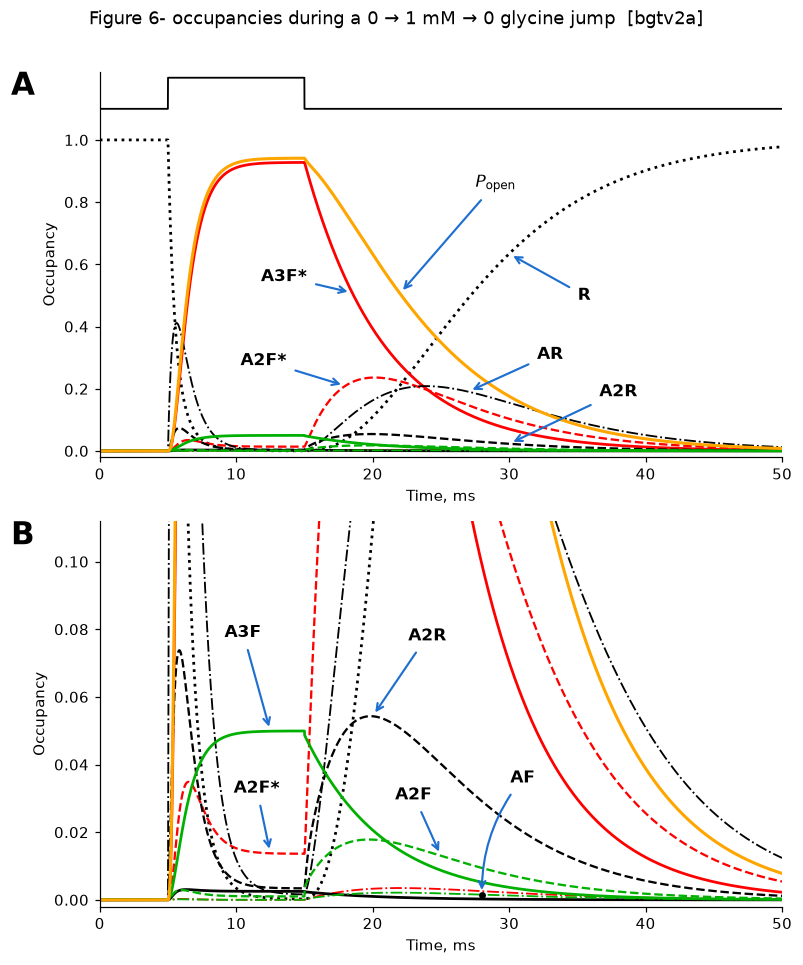

In [17]:
STYLE = {   # colour, linestyle, linewidth, label
    'A3F*': ('red',     '-',  1.8, r'$A_3F^*$'),
    'A2F*': ('red',     '--', 1.5, r'$A_2F^*$'),
    'AF*':  ('red',     '-.', 1.2, r'$AF^*$'),
    'A3F':  ('#00b000', '-',  1.8, r'$A_3F$'),
    'A2F':  ('#00b000', '--', 1.5, r'$A_2F$'),
    'AF':   ('#00b000', '-.', 1.2, r'$AF$'),
    'A3R':  ('black',   '-',  1.8, r'$A_3R$'),
    'A2R':  ('black',   '--', 1.5, r'$A_2R$'),
    'AR':   ('black',   '-.', 1.2, r'$AR$'),
    'R':    ('black',   ':',  1.8, r'$R$'),
}
DRAW = ['R', 'A3F*', 'A2F*', 'AF*', 'A3R', 'A2R', 'AR', 'A3F', 'A2F', 'AF']

fig, (axA, axB) = plt.subplots(2, 1, figsize=(7.5, 9))
for ax, ylim, panel in ((axA, (-0.02, 1.22), 'A'), (axB, (-0.002, 0.112), 'B')):
    for n in DRAW:
        col, ls, lw, _ = STYLE[n]
        ax.plot(t_ms, jump.P[BG.i(n)], color=col, ls=ls, lw=lw)
    ax.plot(t_ms, jump.Popen, color='orange', lw=2.0)
    if panel == 'A':
        ax.plot(t_ms, 1.10 + 0.10 * jump.c / CMAX, color='black', lw=1.2)
        ax.set_yticks([0, .2, .4, .6, .8, 1.0])
    else:
        ax.set_yticks([0, .02, .04, .06, .08, .10])
    ax.set_xlim(0, RECLEN * 1e3); ax.set_ylim(*ylim)
    ax.set_xlabel('Time, ms'); ax.set_ylabel('Occupancy')
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(-0.13, 1.0, panel, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top')

# Label the traces in the panels, as the published figure does. The published
# figure carries no legend box; it names six traces in A and four in B with
# bold labels and blue arrows. The same ones are named here, with the one
# correction - what the published panel B labels AF is A3F - and with AF added
# at its true position, hard against the abscissa, since that is the point of
# the correction.
ARROW = '#1f6fd0'


def trace_at(name, x_ms):
    return jump.P[BG.i(name)][int(np.searchsorted(t_ms, x_ms))]


def label(ax, text, x_text, y_text, name, x_anchor, mark=False, rad=0.0):
    y = trace_at(name, x_anchor)
    if mark:
        ax.plot([x_anchor], [y], marker='o', ms=3.5, color='black', zorder=6)
    ax.annotate(text, xy=(x_anchor, y), xytext=(x_text, y_text),
                fontsize=11, fontweight='bold', color='black',
                ha='center', va='center', zorder=6,
                arrowprops=dict(arrowstyle='->', color=ARROW, lw=1.4,
                                shrinkA=4, shrinkB=3,
                                connectionstyle='arc3,rad=%g' % rad))


axA.annotate(r'$P_{\rm open}$',
             xy=(22.0, jump.Popen[int(np.searchsorted(t_ms, 22.0))]),
             xytext=(29.0, 0.86), fontsize=11, fontweight='bold', color='black',
             ha='center', va='center', zorder=6,
             arrowprops=dict(arrowstyle='->', color=ARROW, lw=1.4,
                             shrinkA=4, shrinkB=3))
label(axA, 'A3F*', 13.5, 0.56, 'A3F*', 18.5)
label(axA, 'A2F*', 12.0, 0.29, 'A2F*', 18.0)
label(axA, 'R',    35.5, 0.50, 'R',    30.0)
label(axA, 'AR',   33.0, 0.31, 'AR',   27.0)
label(axA, 'A2R',  38.0, 0.19, 'A2R',  30.0)

label(axB, 'A3F',  10.5, 0.079, 'A3F',  12.5)
label(axB, 'A2F*', 11.5, 0.033, 'A2F*', 12.5)
label(axB, 'A2R',  24.0, 0.078, 'A2R',  20.0)
label(axB, 'A2F',  23.0, 0.031, 'A2F',  25.0)
label(axB, 'AF',   31.0, 0.036, 'AF',   28.0, mark=True, rad=0.18)

fig.suptitle('Figure 6- occupancies during a 0 → 1 mM → 0 glycine jump  [bgtv2a]')
fig.tight_layout(rect=[0.02, 0.01, 1, 0.97])
plt.show()

## 7.1 The numbers quoted in the Fig. 6 text

> *"Diliganded openings (A₂F\*, red dashed line) rise to a peak of around 3.5 %
> during the pulse, and then decline as a third ligand is bound. During offset,
> diliganded openings rise to a peak of over 20 % and in the later stages of
> decay there are more diliganded than triliganded channels."*

In [18]:
on = (jump.t > PREPULSE) & (jump.t <= PREPULSE + WIDTH)
off = jump.t > PREPULSE + WIDTH

def peak(name, mask):
    y = jump.P[BG.i(name)][mask]
    i = int(np.argmax(y))
    return y[i], t_ms[mask][i]

pk_on, t_on = peak('A2F*', on)
pk_off, t_off = peak('A2F*', off)
late = jump.t > 35e-3

print('A2F* peak during the pulse  : %6.3f %% at %5.2f ms   paper "around 3.5%%"'
      % (100*pk_on, t_on))
print('A2F* peak during the offset : %6.3f %% at %5.2f ms   paper "over 20%%"'
      % (100*pk_off, t_off))
print('Popen plateau               : %6.4f' % jump.Popen[on].max())
print('more diliganded than triliganded open channels after 35 ms? %s'
      % bool(np.all(jump.P[BG.i('A2F*')][late] > jump.P[BG.i('A3F*')][late])))

A2F* peak during the pulse  :  3.488 % at  6.50 ms   paper "around 3.5%"
A2F* peak during the offset : 23.595 % at 20.15 ms   paper "over 20%"
Popen plateau               : 0.9412
more diliganded than triliganded open channels after 35 ms? True


The plateau at 0.05 during the pulse is `A3F` (Table 1: 4.99 %).

> **Two traces are interchanged in the published panel B.** The trace labelled
> `AF` there is in fact `A3F`, and vice versa; the line styles went with the
> labels rather than with the traces, so the plateau is also drawn dash-dot
> although the legend assigns solid lines to triliganded states.
>
> The identification is not marginal. The cell below gives the two occupancies
> 12 ms into the pulse, and Table 1 gives the corresponding equilibrium values
> at 1 mM: `A3F` = 4.99 %, `AF` = 0.0007 %. A trace at 0.05 can only be `A3F`.
>
> This is the subject of a corrigendum to the paper.

In [19]:
i12 = int(np.searchsorted(t_ms, 12.0))
for n in ('A3F', 'A2F', 'AF'):
    print('p(%-4s) at t = 12 ms = %.7f' % (n, jump.P[BG.i(n)][i12]))

p(A3F ) at t = 12 ms = 0.0498142
p(A2F ) at t = 12 ms = 0.0010377
p(AF  ) at t = 12 ms = 0.0000077


## 7.2 Mechanism diagram helper (used for Figures 7 and 8)

Figures 7 and 8 are the mechanism of Fig. 3 with a number written against every
arrow. The helper below lays the ten states out as in Fig. 3- resting on top,
flipped in the middle, open at the bottom- and labels each of the 22 directed
transitions.

In [20]:
LAYOUT = {   # state -> (x, y, paper state number)
    'R':   (0, 2, 10), 'AR':   (1, 2, 9), 'A2R':  (2, 2, 8), 'A3R':  (3, 2, 7),
    'AF':  (1, 1, 6),  'A2F':  (2, 1, 5), 'A3F':  (3, 1, 4),
    'AF*': (1, 0, 1),  'A2F*': (2, 0, 2), 'A3F*': (3, 0, 3),
}
EDGES = [('R', 'AR'), ('AR', 'A2R'), ('A2R', 'A3R'),
         ('AF', 'A2F'), ('A2F', 'A3F'),
         ('AR', 'AF'), ('A2R', 'A2F'), ('A3R', 'A3F'),
         ('AF', 'AF*'), ('A2F', 'A2F*'), ('A3F', 'A3F*')]
SLAB = {'R': '$R$', 'AR': '$AR$', 'A2R': '$A_2R$', 'A3R': '$A_3R$',
        'AF': '$AF$', 'A2F': '$A_2F$', 'A3F': '$A_3F$',
        'AF*': '$AF^*$', 'A2F*': '$A_2F^*$', 'A3F*': '$A_3F^*$'}
ROWCOL = {2: 'black', 1: '#00992b', 0: '#d40000'}   # resting / flipped / open


def fmt3(v):
    """Three significant figures, compact."""
    if v == 0:
        return '0'
    a = abs(v)
    if a >= 1000:
        return '%.0f' % v
    if a >= 1e-3:
        return '%.3g' % v
    return '%.1e' % v


def draw_mechanism(M, model, title='', fmt_fn=fmt3, ax=None, figsize=(11, 6.2)):
    """Draw the flip mechanism, labelling each directed edge i->j with M[i, j]."""
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    off, shrink = 0.085, 0.32

    for a, b in EDGES:
        horiz = LAYOUT[a][1] == LAYOUT[b][1]
        for s, t, sign in ((a, b, +1), (b, a, -1)):
            xs, ys, _ = LAYOUT[s]
            xt, yt, _ = LAYOUT[t]
            val = fmt_fn(M[model.i(s), model.i(t)])
            if horiz:
                y = ys + sign * off
                x0, x1 = min(xs, xt) + shrink, max(xs, xt) - shrink
                if xs > xt:
                    x0, x1 = x1, x0
                ax.annotate('', xy=(x1, y), xytext=(x0, y),
                            arrowprops=dict(arrowstyle='-|>', lw=1.1, color='0.35',
                                            shrinkA=0, shrinkB=0))
                ax.text((x0 + x1) / 2, y + sign * 0.05, val, ha='center',
                        va='bottom' if sign > 0 else 'top', fontsize=8.5)
            else:
                x = xs + sign * off
                y0, y1 = min(ys, yt) + shrink, max(ys, yt) - shrink
                if ys > yt:
                    y0, y1 = y1, y0
                ax.annotate('', xy=(x, y1), xytext=(x, y0),
                            arrowprops=dict(arrowstyle='-|>', lw=1.1, color='0.35',
                                            shrinkA=0, shrinkB=0))
                ax.text(x + sign * 0.03, (y0 + y1) / 2, val, rotation=90,
                        ha='left' if sign > 0 else 'right', va='center', fontsize=8.5)

    for name, (x, y, pno) in LAYOUT.items():
        ax.text(x, y, SLAB[name], ha='center', va='center', fontsize=15,
                color=ROWCOL[y], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='none'))
        ax.text(x, y - 0.17, str(pno), ha='center', va='center',
                fontsize=8, color='steelblue')

    ax.set_xlim(-0.5, 3.6); ax.set_ylim(-0.5, 2.45); ax.axis('off')
    if title:
        ax.set_title(title, fontsize=11)
    return ax

# 8 Figure 7- transition probabilities

The probability that the next transition out of state $i$, whenever it happens,
goes to state $j$ (paper Eq. 2; Colquhoun & Hawkes 1982, Eq. 1.5):

$$\pi_{ij} = \frac{q_{ij}}{\sum_{j \neq i} q_{ij}} = -\frac{q_{ij}}{q_{ii}}.$$

These are independent of time and do **not** require equilibrium, but they do
depend on concentration. The probabilities on all arrows leaving a state sum to 1.

In [21]:
PI = {c: transition_probability(BG.Q(c)) for c in (C_LOW, C_HIGH)}
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    rs = PI[c].sum(axis=1)
    print('%-6s : row sums min %.10f  max %.10f  (must be 1)' % (tag, rs.min(), rs.max()))

10 uM  : row sums min 1.0000000000  max 1.0000000000  (must be 1)
1 mM   : row sums min 1.0000000000  max 1.0000000000  (must be 1)


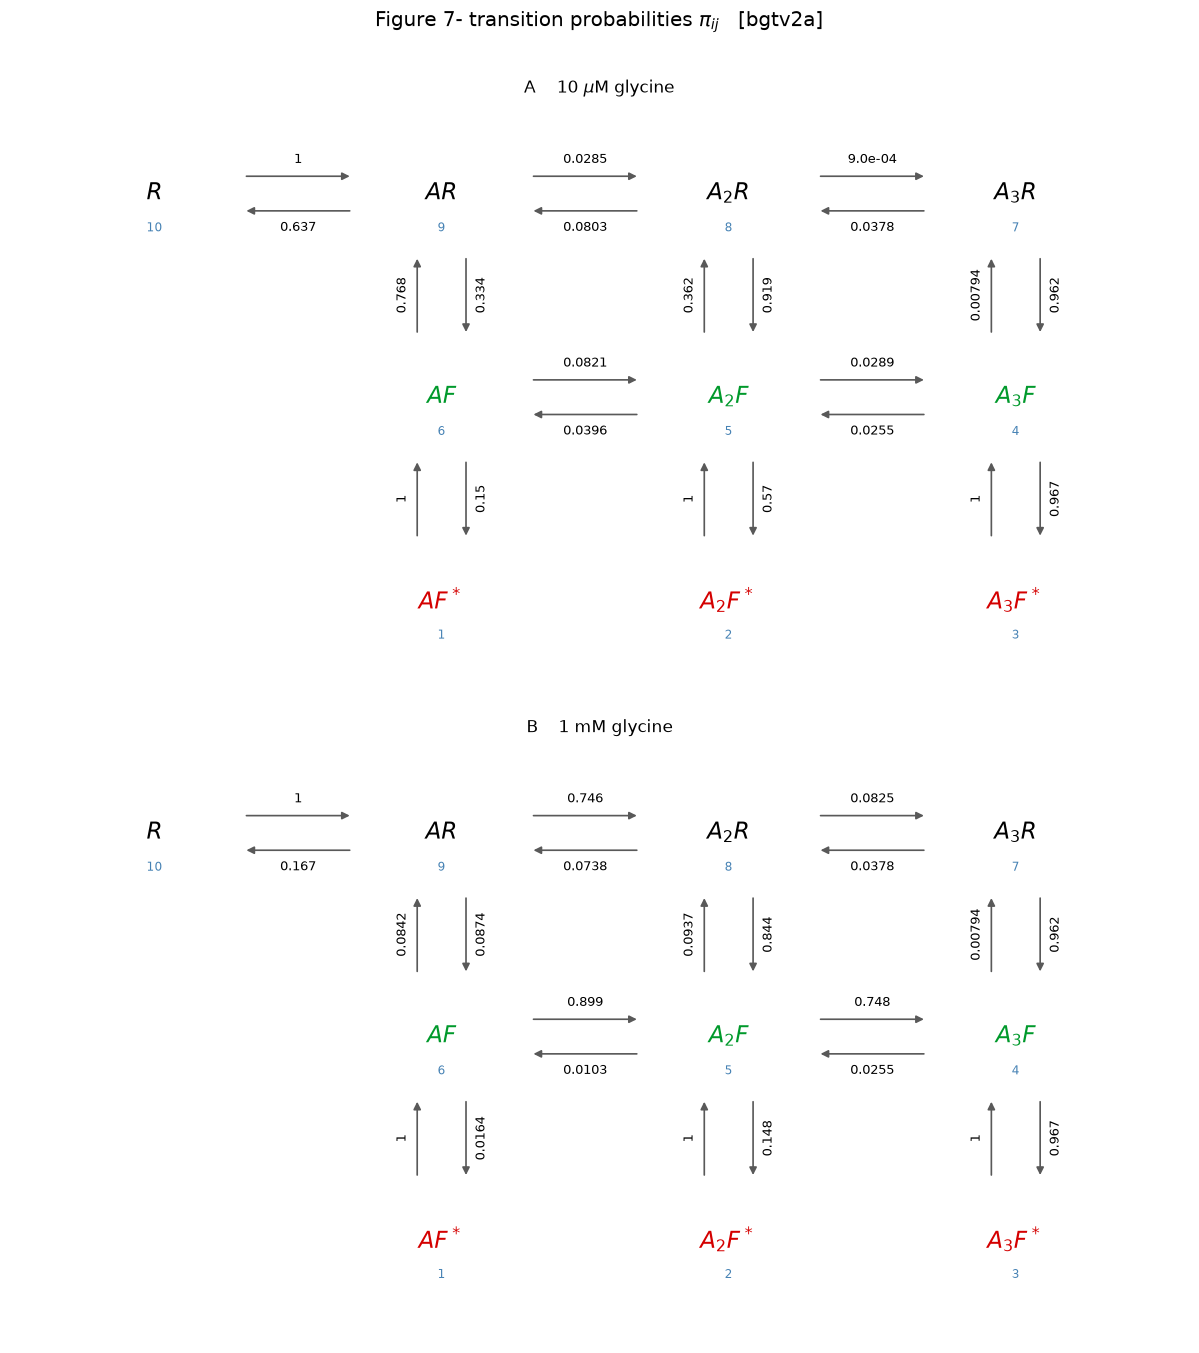

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(11, 12.5))
draw_mechanism(PI[C_LOW],  BG, 'A    10 $\\mu$M glycine', ax=axes[0])
draw_mechanism(PI[C_HIGH], BG, 'B    1 mM glycine',       ax=axes[1])
fig.suptitle('Figure 7- transition probabilities $\\pi_{ij}$   [bgtv2a]', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [23]:
def pi(c, a, b):
    return PI[c][BG.i(a), BG.i(b)]

print('pi(R -> AR) = %.6f at 10 uM and %.6f at 1 mM'
      % (pi(C_LOW, 'R', 'AR'), pi(C_HIGH, 'R', 'AR')))
print('  -> exactly 1, because binding is the only way to leave state 10.')

pi(R -> AR) = 1.000000 at 10 uM and 1.000000 at 1 mM
  -> exactly 1, because binding is the only way to leave state 10.


# 9 Figure 8- transition frequencies at equilibrium

The number of $i \to j$ transitions per second (paper Eq. 3):

$$f_{ij} = p_i(t)\, q_{ij},$$

evaluated here with the equilibrium occupancies $p(\infty)$. Because the
mechanism obeys microscopic reversibility, $f_{ij} = f_{ji}$ at equilibrium-
a useful check on the arithmetic, and one that `bgtv2a` passes to machine
precision.

In [24]:
FREQ = {c: transition_frequency(BG.Q(c), BG.pinf(c))
        for c in (C_LOW, C_HIGH)}
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    d = np.abs(FREQ[c] - FREQ[c].T).max()
    print('%-6s : max |f_ij - f_ji| = %.3e   (%.1e relative)'
          % (tag, d, d / np.abs(FREQ[c]).max()))
print()
print('For comparison, the Fig 3 averaged rates give:')
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    Fa = transition_frequency(AV.Q(c), AV.pinf(c))
    d = np.abs(Fa - Fa.T).max()
    print('%-6s : max |f_ij - f_ji| = %.3e   (%.1e relative)'
          % (tag, d, d / np.abs(Fa).max()))

10 uM  : max |f_ij - f_ji| = 5.626e-08   (2.1e-09 relative)
1 mM   : max |f_ij - f_ji| = 3.407e-08   (5.3e-12 relative)

For comparison, the Fig 3 averaged rates give:
10 uM  : max |f_ij - f_ji| = 1.584e-02   (7.0e-04 relative)
1 mM   : max |f_ij - f_ji| = 5.687e-02   (8.8e-06 relative)


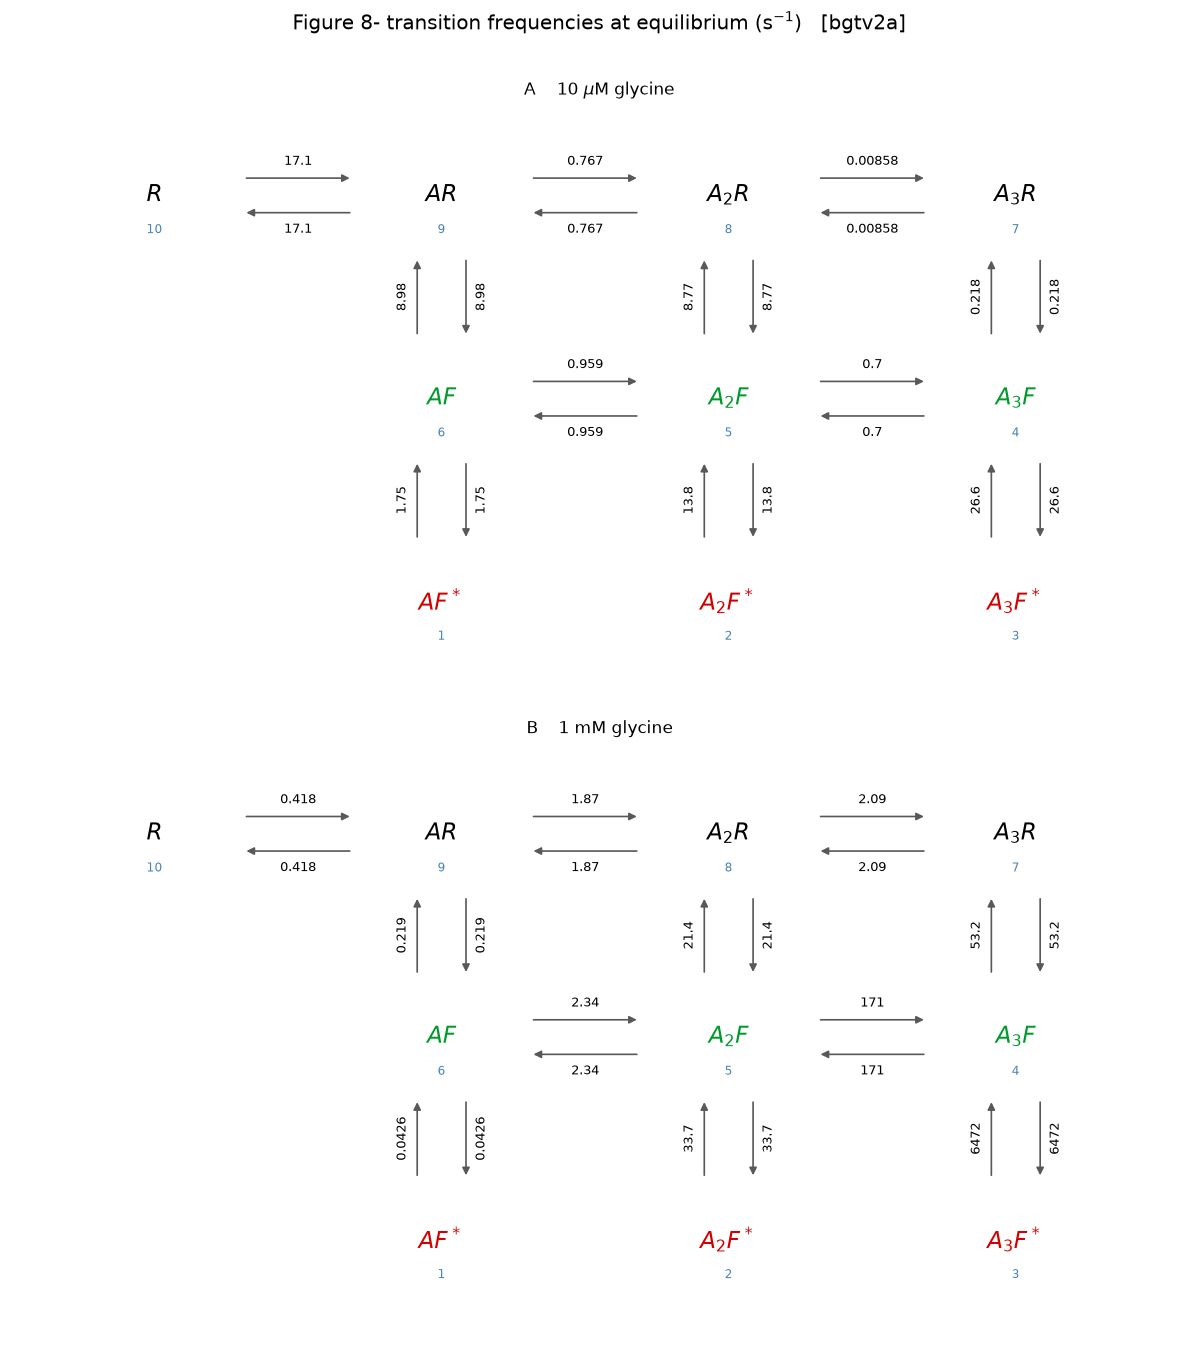

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(11, 12.5))
draw_mechanism(FREQ[C_LOW],  BG, 'A    10 $\\mu$M glycine', ax=axes[0])
draw_mechanism(FREQ[C_HIGH], BG, 'B    1 mM glycine',       ax=axes[1])
fig.suptitle('Figure 8- transition frequencies at equilibrium (s$^{-1}$)   [bgtv2a]',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9.1 The frequencies quoted in the text

> *"At 1 mM glycine … by far the most frequent transition at equilibrium is
> between the fully liganded flipped state and the open state,
> $f_{43} = f_{34} = 6{,}472$ transitions per second … In contrast, the first
> occupancy of the resting state, $f_{10,9}$ is rare, only 0.418 per second …
> the initial frequency of bindings is thus 1,850 bindings per second at
> $t = 0$, and it falls to 0.418 per second at equilibrium."*

In [26]:
def f_(c, a, b):
    return FREQ[c][BG.i(a), BG.i(b)]

q109 = BG.Q(C_HIGH)[BG.i('R'), BG.i('AR')]     # = 3*k(+1)*c
chk = pd.DataFrame([
    ('f43 = f(A3F -> A3F*)', f_(C_HIGH, 'A3F', 'A3F*'), 6472,  's^-1'),
    ('f34 = f(A3F* -> A3F)', f_(C_HIGH, 'A3F*', 'A3F'), 6472,  's^-1'),
    ('f10,9 = f(R -> AR)',   f_(C_HIGH, 'R', 'AR'),     0.418, 's^-1'),
    ('f9,10 = f(AR -> R)',   f_(C_HIGH, 'AR', 'R'),     0.418, 's^-1'),
    ('initial binding rate p10(0)*q10,9 at t=0', q109,  1850,  's^-1'),
], columns=['quantity', 'bgtv2a', 'published', 'units'])
chk['% diff'] = 100 * (chk['bgtv2a'] / chk['published'] - 1)
show(chk.style.format({'bgtv2a': '{:.6g}', 'published': '{:.6g}', '% diff': '{:+.3f}'}))

,quantity,bgtv2a,published,units,% diff
0,f43 = f(A3F -> A3F*),6471.73,6472,s^-1,-0.004
1,f34 = f(A3F* -> A3F),6471.73,6472,s^-1,-0.004
2,"f10,9 = f(R -> AR)",0.417522,0.418,s^-1,-0.114
3,"f9,10 = f(AR -> R)",0.417522,0.418,s^-1,-0.114
4,"initial binding rate p10(0)*q10,9 at t=0",1850.57,1850,s^-1,+0.031


In [27]:
print('initial binding frequency = %.1f s^-1 = %.3f ms^-1 = %.5f us^-1'
      % (q109, q109*1e-3, q109*1e-6))
print('at equilibrium            = %.4f s^-1' % f_(C_HIGH, 'R', 'AR'))
print('ratio = %.0f-fold' % (q109 / f_(C_HIGH, 'R', 'AR')))
print()
print('With 1000 channels, %.0f would associate per second and %.0f dissociate.'
      % (1000*f_(C_HIGH, 'R', 'AR'), 1000*f_(C_HIGH, 'AR', 'R')))
print('(the paper: "With 1,000 channels, 418 would associate per second, and 418')
print(' would dissociate")')

initial binding frequency = 1850.6 s^-1 = 1.851 ms^-1 = 0.00185 us^-1
at equilibrium            = 0.4175 s^-1
ratio = 4432-fold

With 1000 channels, 418 would associate per second and 418 dissociate.
(the paper: "With 1,000 channels, 418 would associate per second, and 418
 would dissociate")


# 10 Preferred routes through the mechanism

Using the transition probabilities of Fig. 7, the probability of a particular
route from the vacant resting receptor $R$ (state 10) to the fully liganded open
state $A_3F^*$ (state 3) is the product of the $\pi_{ij}$ along it. Note
$\pi_{10,9} = 1$, so it drops out.

| Route | Path | Description |
|---|---|---|
| via 8→5 | 10→9→8→**5**→4→3 | flips while **di**liganded |
| clockwise | 10→9→8→**7**→4→3 | binds all three, then flips |
| anticlockwise | 10→9→**6**→5→4→3 | flips while **mono**liganded |

In [28]:
ROUTES = {
    'via 8,5       10>9>8>5>4>3': [('AR','A2R'), ('A2R','A2F'), ('A2F','A3F'), ('A3F','A3F*')],
    'clockwise     10>9>8>7>4>3': [('AR','A2R'), ('A2R','A3R'), ('A3R','A3F'), ('A3F','A3F*')],
    'anticlockwise 10>9>6>5>4>3': [('AR','AF'),  ('AF','A2F'),  ('A2F','A3F'), ('A3F','A3F*')],
}
PUB_R = {'via 8,5       10>9>8>5>4>3': (7.3e-4, 0.455),
         'clockwise     10>9>8>7>4>3': (2.8e-5, 0.0573),
         'anticlockwise 10>9>6>5>4>3': (7.7e-4, 0.0568)}

rows = []
for name, steps in ROUTES.items():
    rows.append({
        'route': name,
        '10 uM bgtv2a': np.prod([pi(C_LOW, a, b) for a, b in steps]),
        '10 uM pub': PUB_R[name][0],
        '1 mM bgtv2a': np.prod([pi(C_HIGH, a, b) for a, b in steps]),
        '1 mM pub': PUB_R[name][1],
    })
routes = pd.DataFrame(rows).set_index('route')
show(routes.style.format('{:.4g}'))

,10 uM bgtv2a,10 uM pub,1 mM bgtv2a,1 mM pub
route,,,,
"via 8,5 10>9>8>5>4>3",0.0007315,0.00073,0.4552,0.455
clockwise 10>9>8>7>4>3,2.385e-05,2.8e-05,0.05727,0.0573
anticlockwise 10>9>6>5>4>3,0.0007654,0.00077,0.05685,0.0568


Five of the six route probabilities match the published values to the printed
precision. The sixth does not, and the discrepancy looks like a misprint in the
paper rather than a difference in the calculation:

> **The clockwise route at 10 µM.** The paper gives 2.8 × 10⁻⁵; `bgtv2a` gives
> **2.385 × 10⁻⁵**, which would print as 2.4 × 10⁻⁵. The same expression,
> $\pi_{98}\pi_{87}\pi_{74}\pi_{43}$, reproduces the 1 mM value (0.05727 against
> a published 0.0573) exactly, so the formula is not in doubt.
>
> The paper's next sentence supports the computed value: it says the other
> two routes are "about 30 times more likely than the clockwise route". With
> 2.385 × 10⁻⁵ those ratios are 30.7 and 32.1; with 2.8 × 10⁻⁵ they would be
> 26.1 and 27.5, which would not have been described as about 30.

The paper's conclusions follow, and are unaffected:

* **At 1 mM** the dominant route flips while *di*liganded (10→9→8→5→4→3) and is
  about 8 times more probable than either route round the outside of the rectangle,
  which are nearly equal to each other.
* **At 10 µM** the anticlockwise route (flipping while *mono*liganded) and the
  route via states 8 and 5 are comparable, and both are ~30× more likely than the
  clockwise route via state 7.

In [29]:
r1, r0 = routes['1 mM bgtv2a'], routes['10 uM bgtv2a']
print('At 1 mM  : dominant route is %.2f x clockwise and %.2f x anticlockwise'
      % (r1.iloc[0]/r1.iloc[1], r1.iloc[0]/r1.iloc[2]))
print('           paper: "about 8 times larger than ... either of the routes round the outside"')
print('           clockwise / anticlockwise = %.3f  (paper: nearly equal)'
      % (r1.iloc[1]/r1.iloc[2]))
print()
print('At 10 uM : via-8,5 / clockwise = %.0f x ;  anticlockwise / clockwise = %.0f x'
      % (r0.iloc[0]/r0.iloc[1], r0.iloc[2]/r0.iloc[1]))
print('           paper: "both are about 30 times more likely than the clockwise route"')

At 1 mM  : dominant route is 7.95 x clockwise and 8.01 x anticlockwise
           paper: "about 8 times larger than ... either of the routes round the outside"
           clockwise / anticlockwise = 1.007  (paper: nearly equal)

At 10 uM : via-8,5 / clockwise = 31 x ;  anticlockwise / clockwise = 32 x
           paper: "both are about 30 times more likely than the clockwise route"


## 10.1 Conditional probabilities (Eqs 4 and 5)

The paper refines the calculation by noting that opening while mono- or
diliganded is irrelevant to reaching $A_3F^*$ by this route, so $\pi_{54}$ should
be replaced by the probability of a 5→4 transition *given that the channel does
not open*, and likewise for $\pi_{65}$:

$$\frac{\pi_{54}}{1-\pi_{52}}, \qquad \frac{\pi_{65}}{1-\pi_{61}}.$$

The paper concludes these corrections are "sufficiently small that the
conclusions about predominant route are not changed"- checked below by redoing
the route ranking with the corrected probabilities.

In [30]:
rows = []
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    rows.append({'c': tag,
                 'pi54': pi(c, 'A2F', 'A3F'),
                 'pi54/(1-pi52)': pi(c, 'A2F', 'A3F') / (1 - pi(c, 'A2F', 'A2F*')),
                 'pi65': pi(c, 'AF', 'A2F'),
                 'pi65/(1-pi61)': pi(c, 'AF', 'A2F') / (1 - pi(c, 'AF', 'AF*'))})
show(pd.DataFrame(rows).set_index('c').style.format('{:.5g}'))

print('Route probabilities using the conditional forms:')
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    p54c = pi(c, 'A2F', 'A3F') / (1 - pi(c, 'A2F', 'A2F*'))
    p65c = pi(c, 'AF', 'A2F') / (1 - pi(c, 'AF', 'AF*'))
    via85 = pi(c,'AR','A2R') * pi(c,'A2R','A2F') * p54c * pi(c,'A3F','A3F*')
    cw    = pi(c,'AR','A2R') * pi(c,'A2R','A3R') * pi(c,'A3R','A3F') * pi(c,'A3F','A3F*')
    acw   = pi(c,'AR','AF')  * p65c             * p54c * pi(c,'A3F','A3F*')
    order = sorted([('via 8,5', via85), ('clockwise', cw), ('anticlockwise', acw)],
                   key=lambda kv: -kv[1])
    print('  %-6s via8,5 %.4g   clockwise %.4g   anticlockwise %.4g   -> %s'
          % (tag, via85, cw, acw, ' > '.join(k for k, _ in order)))

,pi54,pi54/(1-pi52),pi65,pi65/(1-pi61)
c,,,,
10 uM,0.028877,0.067136,0.082059,0.096484
1 mM,0.74833,0.878,0.89939,0.91437


Route probabilities using the conditional forms:
  10 uM  via8,5 0.001701   clockwise 2.385e-05   anticlockwise 0.002092   -> anticlockwise > via 8,5 > clockwise
  1 mM   via8,5 0.5341   clockwise 0.05727   anticlockwise 0.06781   -> via 8,5 > anticlockwise > clockwise


# 11 Summary- everything against the published values

In [31]:
def summarise(m, jump_pk=None):
    Q = m.Q(C_HIGH)
    F = transition_frequency(Q, m.pinf(C_HIGH))
    P = {c: transition_probability(m.Q(c)) for c in (C_LOW, C_HIGH)}
    p = lambda c, a, b: P[c][m.i(a), m.i(b)]
    pl, ph = m.pinf(C_LOW), m.pinf(C_HIGH)
    d = {
        'Table 1: A3F* at 1 mM (%)':   100*ph[m.i('A3F*')],
        'Table 1: R at 10 uM (%)':     100*pl[m.i('R')],
        'Table 1: AR at 10 uM (%)':    100*pl[m.i('AR')],
        'Table 1: A3F at 1 mM (%)':    100*ph[m.i('A3F')],
        'Table 1: A2F* at 1 mM (%)':   100*ph[m.i('A2F*')],
        'Fig 8: f43 at 1 mM (s^-1)':   F[m.i('A3F'), m.i('A3F*')],
        'Fig 8: f10,9 at 1 mM (s^-1)': F[m.i('R'), m.i('AR')],
        'text: initial binding (s^-1)': Q[m.i('R'), m.i('AR')],
        'text: lifetime of R at 1 mM (ms)': -1e3 / Q[m.i('R'), m.i('R')],
    }
    for nm, steps in ROUTES.items():
        d['route %s at 1 mM' % nm.split()[0]] = np.prod(
            [p(C_HIGH, a, b) for a, b in steps])
    return d

PUB = {
    'Table 1: A3F* at 1 mM (%)': 92.77, 'Table 1: R at 10 uM (%)': 92.57,
    'Table 1: AR at 10 uM (%)': 6.21,   'Table 1: A3F at 1 mM (%)': 4.99,
    'Table 1: A2F* at 1 mM (%)': 1.36,
    'Fig 8: f43 at 1 mM (s^-1)': 6472,  'Fig 8: f10,9 at 1 mM (s^-1)': 0.418,
    'text: initial binding (s^-1)': 1850,
    'text: lifetime of R at 1 mM (ms)': 0.54,
    'route via at 1 mM': 0.455, 'route clockwise at 1 mM': 0.0573,
    'route anticlockwise at 1 mM': 0.0568,
}

summary = pd.DataFrame({'published': PUB, 'bgtv2a': summarise(BG),
                        'averaged': summarise(AV)})
summary['bgtv2a % err'] = 100 * (summary['bgtv2a'] / summary['published'] - 1)
summary['averaged % err'] = 100 * (summary['averaged'] / summary['published'] - 1)
show(
summary.style.format({'published': '{:.5g}', 'bgtv2a': '{:.5g}', 'averaged': '{:.5g}',
                      'bgtv2a % err': '{:+.2f}', 'averaged % err': '{:+.2f}'}) \
       .background_gradient(cmap='RdYlGn_r', subset=['bgtv2a % err'], vmin=-20, vmax=20) \
       .background_gradient(cmap='RdYlGn_r', subset=['averaged % err'], vmin=-20, vmax=20))

,published,bgtv2a,averaged,bgtv2a % err,averaged % err
Table 1: A3F* at 1 mM (%),92.77,92.775,92.525,+0.01,-0.26
Table 1: R at 10 uM (%),92.57,92.567,93.362,-0.00,+0.86
Table 1: AR at 10 uM (%),6.21,6.2147,5.5083,+0.08,-11.30
Table 1: A3F at 1 mM (%),4.99,4.9932,5.0207,+0.06,+0.62
Table 1: A2F* at 1 mM (%),1.36,1.3617,1.6071,+0.13,+18.17
Fig 8: f43 at 1 mM (s^-1),6472,6471.7,6476.7,-0.00,+0.07
"Fig 8: f10,9 at 1 mM (s^-1)",0.418,0.41752,0.4851,-0.11,+16.05
text: initial binding (s^-1),1850,1850.6,1770,+0.03,-4.32
text: lifetime of R at 1 mM (ms),0.54,0.54037,0.56497,+0.07,+4.62
route via at 1 mM,0.455,0.45522,0.44197,+0.05,-2.86


## 11.1 Reading the summary

With `bgtv2a` every quantity agrees with the paper to within the precision the
paper prints- typically a few hundredths of a percent, and the residuals are
consistent with the published values having been rounded to 3–4 significant
figures rather than with any difference in the calculation.

The `averaged` column shows what the Fig. 3 mean rate constants give: fine for
the dominant occupancies and for $f_{43}$, but 11–26 % out on the quantities that
depend on the smallest occupancy ($p_R$ = 0.023 %) or on the association rate,
and it misorders the two outside routes at 1 mM. That column is a useful caution:
reproducing a paper from the rate constants in a mechanism *figure* is not always
the same as reproducing it from the rate constants actually used.

## 11.2 Where the two datasets came from

| | source | microscopic reversibility |
|---|---|---|
| `bgtv2a.mec` | one fitted dataset, Burzomato et al. 2004 | exact |
| `GlyR_flip` | mean of three datasets, as drawn in Fig. 3 | 3–4 % off |

# 12 Automated verification

The cell below raises if any of the published values stops being reproduced, so
running this notebook non-interactively

```
jupyter nbconvert --to notebook --execute ColquhounLape2012_reproduction.ipynb
```

is a regression test on the paper's numbers, not merely a check that the code
runs. This is what continuous integration executes.

In [32]:
TOL = 0.25          # per cent; the largest residual actually observed is 0.13 %

# 1. every published value, against the paper
bad = summary.index[abs(summary['bgtv2a % err']) > TOL].tolist()
assert not bad, 'no longer reproduced to %.2f %%: %s' % (TOL, bad)
print('%d published values reproduced to within %.2f %%   (max |err| = %.3f %%)'
      % (len(summary), TOL, summary['bgtv2a % err'].abs().max()))

# 2. the Fig. 6 B identification: the plateau at ~0.05 is A3F, not AF
p_a3f = jump.P[BG.i('A3F')][i12]
p_af = jump.P[BG.i('AF')][i12]
assert p_a3f > 0.04, 'A3F plateau missing: %g' % p_a3f
assert p_af < 1e-5, 'AF unexpectedly large: %g' % p_af
print('Fig 6B at t = 12 ms:  A3F = %.5f   AF = %.7f   ratio = %.0f'
      % (p_a3f, p_af, p_a3f / p_af))

# 3. the embedded rate constants obey microscopic reversibility
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    Fm = transition_frequency(BG.Q(c), BG.pinf(c))
    rel = np.abs(Fm - Fm.T).max() / np.abs(Fm).max()
    assert rel < 1e-6, 'reversibility violated at %s: %g' % (tag, rel)
    print('microscopic reversibility at %-6s: %.2e relative' % (tag, rel))

# 4. the embedded matrix is a proper Q matrix
for c, tag in ((C_LOW, '10 uM'), (C_HIGH, '1 mM')):
    assert np.abs(BG.Q(c).sum(axis=1)).max() < 1e-6
    assert abs(BG.pinf(c).sum() - 1.0) < 1e-9
print('\nALL CHECKS PASSED')

12 published values reproduced to within 0.25 %   (max |err| = 0.129 %)
Fig 6B at t = 12 ms:  A3F = 0.04981   AF = 0.0000077   ratio = 6445
microscopic reversibility at 10 uM : 2.12e-09 relative
microscopic reversibility at 1 mM  : 5.26e-12 relative

ALL CHECKS PASSED
